In [2]:
from transformers import GPT2LMHeadModel

model_hf = GPT2LMHeadModel.from_pretrained('gpt2') # 124M

/Users/davidharmeyer/Documents/Github/ML/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 10091.97it/s]


In [4]:
sd_hf = model_hf.state_dict()
for k, v in sd_hf.items():
	print(k, v.shape)

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

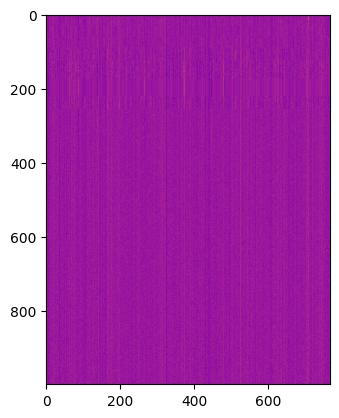

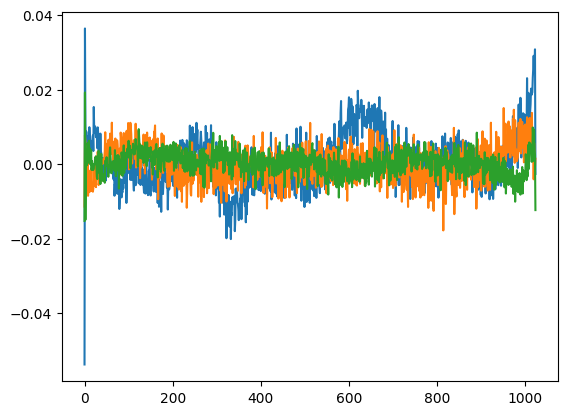

In [26]:
import matplotlib.pyplot as plt
plt.imshow(sd_hf['transformer.wte.weight'][:1000], cmap="plasma")
plt.show()

# these start as random noise, and become smoother as we train the model
plt.plot(sd_hf['transformer.wpe.weight'][:, 200])
plt.plot(sd_hf['transformer.wpe.weight'][:, 201])
plt.plot(sd_hf['transformer.wpe.weight'][:, 203])
plt.show()


In [1]:
from transformers import pipeline, set_seed

generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator("Good morning! The weather", max_length=30, num_return_sequences=5)


/Users/davidharmeyer/Documents/Github/ML/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 8465.37it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] 

[{'generated_text': "Good morning! The weather is fantastic, and I am having a great time with my family.\n\nI had just finished a quick breakfast, and with my brother and I were sitting with a bunch of friends from the local shop. We had already made it to the shop by 3am, but we had a huge queue ahead of us waiting for us to get to it. Luckily, the queue for the shop was already pretty long, so we just got our order in. We got the order of 4, so there was no waiting for us to get to the shop, and I was surprised when I heard the shopkeeper said, 'Wait, we have a couple of hours left'.\n\nI was like, 'I don't know what to do with that.' I was like, 'Okay, I'll just wait a bit longer then.' After being told it was going to take us 2 hours, I started to panic. I was so scared, I didn't want to get into the shop. When I got outside, I saw the police standing by, but didn't want to get into the shop. I wasn't being aggressive as I was scared, I just wanted to see the police, to check on t

In [8]:
import torch
import torch.nn as nn

block_size: int = 256 # context length
vocab_size: int = 65
n_layer: int = 6
n_head: int = 6
n_embed: int = 384
batch_size = 32


x = torch.randn((batch_size, block_size, n_embed))
linear = nn.Linear(n_embed, 3*n_embed)
qkv = linear(x)


